In [1]:
import re
import ast
import matplotlib.pyplot as plt
import numpy as np
import os


📂 正在读取文件: /Users/zzzsy/project/RLHF/code/rlREMOVEDcode/logs/f/ppo_kl/train_20260203_100017.log ...

📊 成功提取数据点: 131 个
✅ 正在绘制三条 Raw Curves...
📷 图片已保存为: /Users/zzzsy/project/RLHF/code/rlREMOVEDcode/logs/f/ppo_kl/figs/training_analysis_llama3-8b_advan_1e-6_Symmetric_2048.png


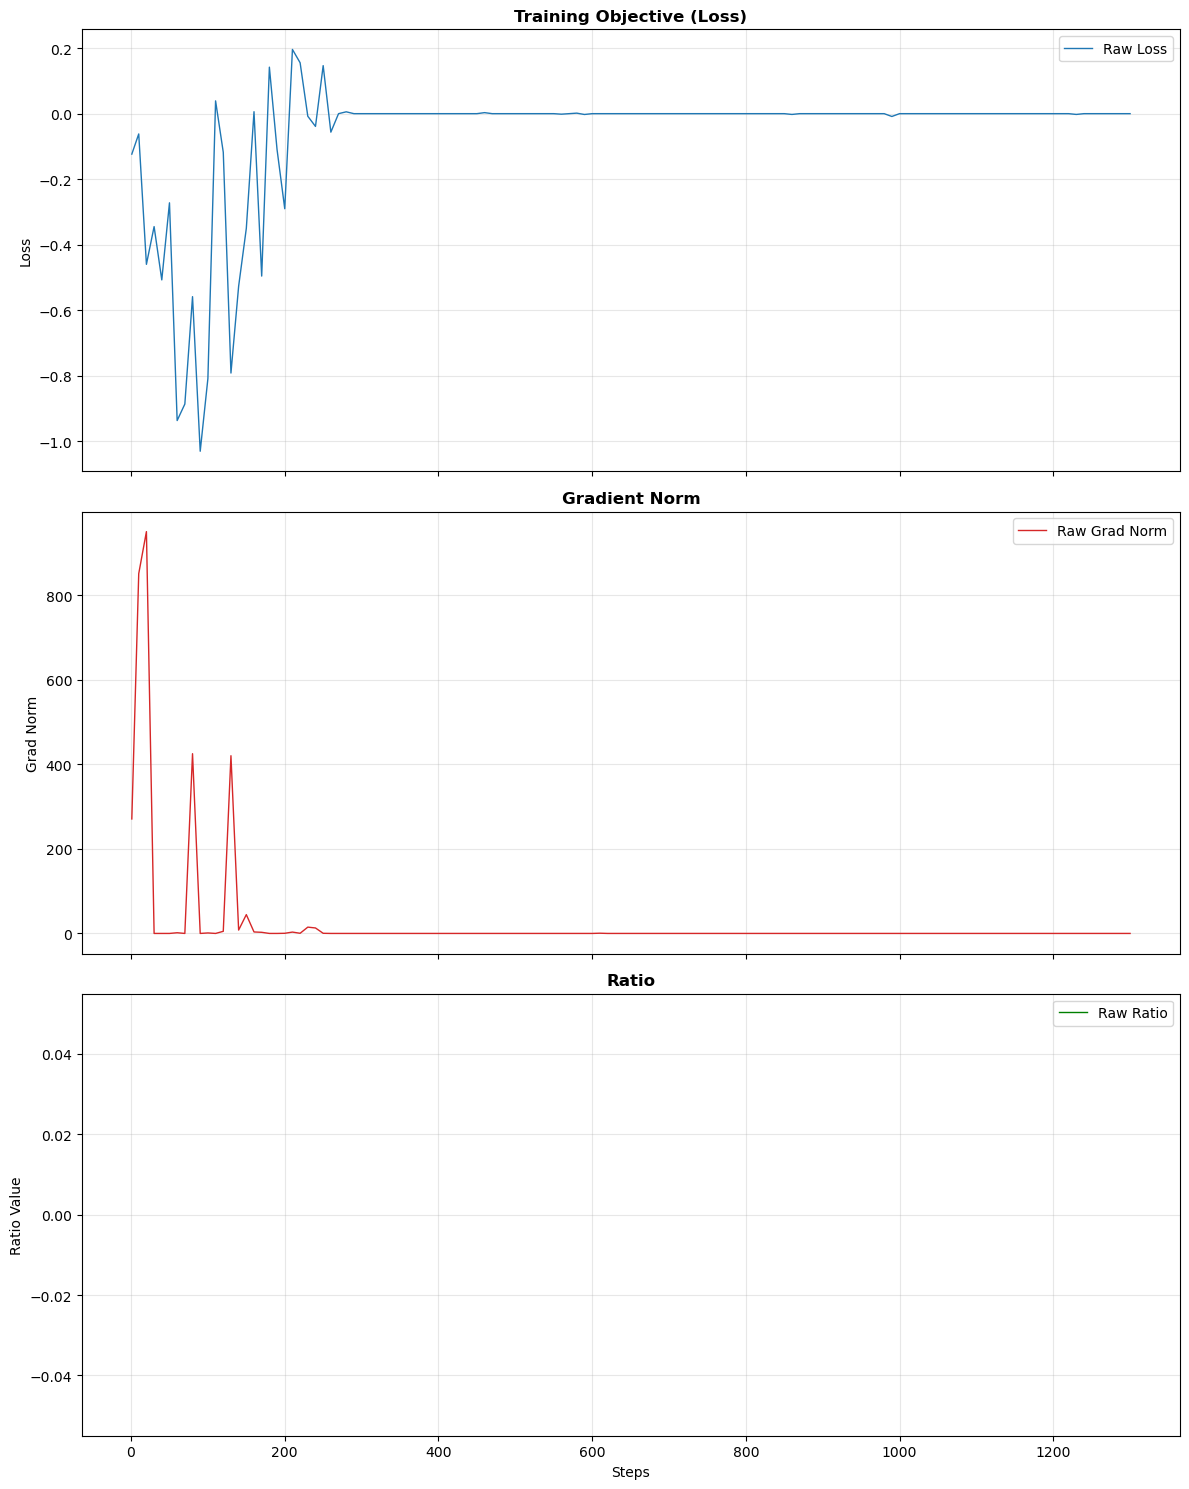

In [2]:
import re
import ast
import matplotlib.pyplot as plt
import os

# ================= 配置区域 =================
LOG_FILE_PATH = '/Users/zzzsy/project/RLHF/code/rlREMOVEDcode/logs/f/ppo_kl/train_20260203_100017.log'
# ===========================================

def parse_log_with_ratio(filepath):
    steps = []
    losses = []
    grad_norms = []
    ratios = []  # 新增：用于存储 ratio 数据
    
    # 状态变量
    last_seen_step = None
    
    # 正则
    step_pattern = re.compile(r'(\d+)/(\d+)')
    dict_start_pattern = re.compile(r"\{'loss':")

    print(f"📂 正在读取文件: {filepath} ...")
    
    if not os.path.exists(filepath):
        print("❌ 文件不存在！")
        return [], [], [], []

    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            
            # 1. 找步数
            step_match = step_pattern.search(line)
            if step_match:
                last_seen_step = int(step_match.group(1))
            
            # 2. 找字典
            if dict_start_pattern.search(line):
                if last_seen_step is not None:
                    try:
                        start_idx = line.find("{")
                        dict_str = line[start_idx:]
                        metrics = ast.literal_eval(dict_str)
                        
                        # 提取所有需要的指标
                        steps.append(last_seen_step)
                        losses.append(metrics.get('loss', float('nan')))
                        grad_norms.append(metrics.get('grad_norm', float('nan')))
                        ratios.append(metrics.get('ratio_mean', float('nan'))) # 提取 ratio
                        
                    except Exception:
                        continue

    return steps, losses, grad_norms, ratios

# --- 主程序 ---
steps, losses, grad_norms, ratios = parse_log_with_ratio(LOG_FILE_PATH)

print(f"\n📊 成功提取数据点: {len(steps)} 个")

if len(steps) > 0:
    print("✅ 正在绘制三条 Raw Curves...")
    
    # 创建 3 行 1 列的图表，sharex=True 表示共享 X 轴（步数）
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 15), sharex=True)

    # --- 1. Loss ---
    ax1.plot(steps, losses, color='#1f77b4', linewidth=1, label='Raw Loss')
    ax1.set_title('Training Objective (Loss)', fontweight='bold')
    ax1.set_ylabel('Loss')
    # ax1.set_ylim(-1, 1)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')

    # --- 2. Grad Norm ---
    ax2.plot(steps, grad_norms, color='#d62728', linewidth=1, label='Raw Grad Norm')
    ax2.set_title('Gradient Norm', fontweight='bold')
    ax2.set_ylabel('Grad Norm')
    # ax2.set_ylim(0, 5000)
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper right')

    # --- 3. Ratio (新增) ---
    ax3.plot(steps, ratios, color='green', linewidth=1, label='Raw Ratio')
    ax3.set_title('Ratio', fontweight='bold')
    ax3.set_ylabel('Ratio Value')
    # ax3.set_ylim(0, 100)
    ax3.set_xlabel('Steps') # 只在最底部的图显示 x 轴标签
    ax3.grid(True, alpha=0.3)
    ax3.legend(loc='upper right')

    plt.tight_layout()
    
    save_path = '/Users/zzzsy/project/RLHF/code/rlREMOVEDcode/logs/f/ppo_kl/figs/training_analysis_llama3-8b_advan_1e-6_Symmetric_2048.png'
    plt.savefig(save_path, dpi=300)
    print(f"📷 图片已保存为: {save_path}")
    plt.show()
else:
    print("❌ 未提取到数据。")

📂 正在读取文件: /Users/zzzsy/project/RLHF/code/rlREMOVEDcode/logs/f/ppo_kl/kl_log/train_20260227_184200.log ...

📊 成功提取数据点: 100 个
✅ 正在绘制 Loss 和 Grad Norm...
📷 图片已保存为: /Users/zzzsy/project/RLHF/code/rlREMOVEDcode/logs/f/ppo_kl/kl_log/fig/training_asymmetric_mini.png


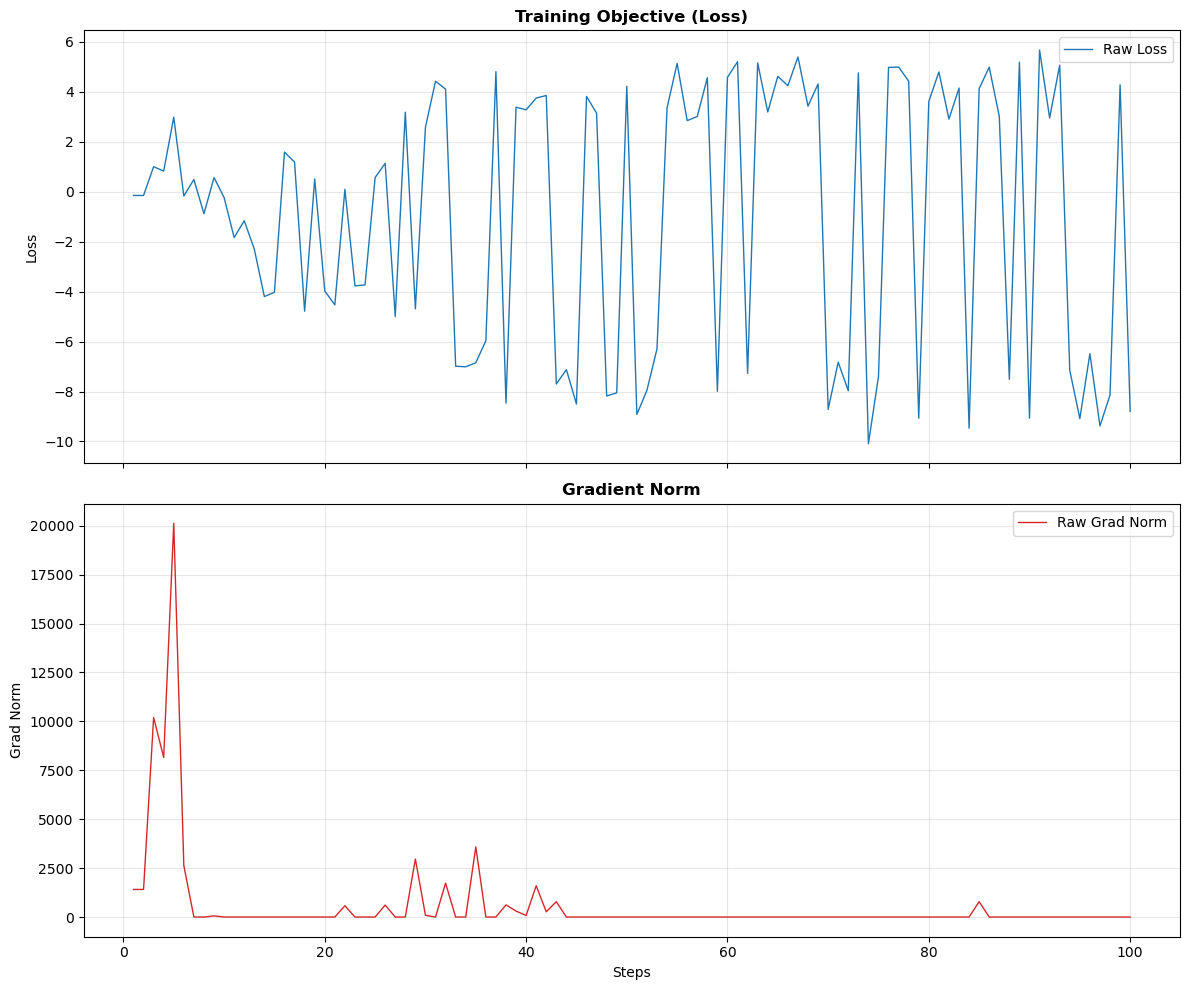

In [4]:
import re
import ast
import matplotlib.pyplot as plt
import os

# ================= 配置区域 =================
LOG_FILE_PATH = '/Users/zzzsy/project/RLHF/code/rlREMOVEDcode/logs/f/ppo_kl/kl_log/train_20260227_184200.log'
SAVE_FIG_PATH = '/Users/zzzsy/project/RLHF/code/rlREMOVEDcode/logs/f/ppo_kl/kl_log/fig/training_asymmetric_mini.png'
# ===========================================

def parse_log(filepath):
    steps = []
    losses = []
    grad_norms = []
    # ratios = [] # 不需要 ratio 了
    
    last_seen_step = None
    step_pattern = re.compile(r'(\d+)/(\d+)')
    dict_start_pattern = re.compile(r"\{'loss':")

    print(f"📂 正在读取文件: {filepath} ...")
    
    if not os.path.exists(filepath):
        print("❌ 文件不存在！")
        return [], [], []

    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            
            step_match = step_pattern.search(line)
            if step_match:
                last_seen_step = int(step_match.group(1))
            
            if dict_start_pattern.search(line):
                if last_seen_step is not None:
                    try:
                        start_idx = line.find("{")
                        dict_str = line[start_idx:]
                        metrics = ast.literal_eval(dict_str)
                        
                        steps.append(last_seen_step)
                        losses.append(metrics.get('loss', float('nan')))
                        grad_norms.append(metrics.get('grad_norm', float('nan')))
                        # 这里不再提取 ratio
                        
                    except Exception:
                        continue

    return steps, losses, grad_norms

# --- 主程序 ---
steps, losses, grad_norms = parse_log(LOG_FILE_PATH)

print(f"\n📊 成功提取数据点: {len(steps)} 个")

if len(steps) > 0:
    print("✅ 正在绘制 Loss 和 Grad Norm...")
    
    # 1. 修改：将 (3, 1) 改为 (2, 1)，并且解包只取 ax1, ax2
    # figsize 高度可以稍微调小一点，比如 (12, 10)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # --- 1. Loss ---
    ax1.plot(steps, losses, color='#1f77b4', linewidth=1, label='Raw Loss')
    ax1.set_title('Training Objective (Loss)', fontweight='bold')
    ax1.set_ylabel('Loss')
    # ax1.set_ylim(-1, 100) # 根据需要调整
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')

    # --- 2. Grad Norm ---
    ax2.plot(steps, grad_norms, color='#d62728', linewidth=1, label='Raw Grad Norm')
    ax2.set_title('Gradient Norm', fontweight='bold')
    ax2.set_ylabel('Grad Norm')
    # ax2.set_ylim(0, 5000) # 根据需要调整
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper right')
    
    # 2. 修改：将 X 轴标签设置在 ax2 上
    ax2.set_xlabel('Steps') 

    plt.tight_layout()
    
    # 确保保存目录存在
    os.makedirs(os.path.dirname(SAVE_FIG_PATH), exist_ok=True)
    
    plt.savefig(SAVE_FIG_PATH, dpi=300)
    print(f"📷 图片已保存为: {SAVE_FIG_PATH}")
    plt.show()
else:
    print("❌ 未提取到数据。")